17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000, Test samples: 25000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 241ms/step - accuracy: 0.7852 - loss: 0.4459 - val_accuracy: 0.8618 - val_loss: 0.3290
Epoch 2/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 222ms/step - accuracy: 0.8989 - loss: 0.2572 - val_accuracy: 0.8616 - val_loss: 0.3145
Epoch 3/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 226ms/step - accuracy: 0.9312 - loss: 0.1840 - val_accuracy: 0.8654 - val_loss: 0.3717
Epoch 4/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.9485 - loss: 0.1410 - val_accuracy: 0.8526 - val_loss: 0.3620
Epoch 5/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 225ms/step - accuracy: 0.9582 - loss: 0.1178 - val_accuracy: 0.8620 - val_loss: 0.4059
Epoch 6/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9736 - loss: 0.0805 - val_accuracy: 0.8586 - val_loss: 0.4631
Epoch 7/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.9566 - loss: 0.1179 - val_accuracy: 0.8624 - val_loss: 0.4990


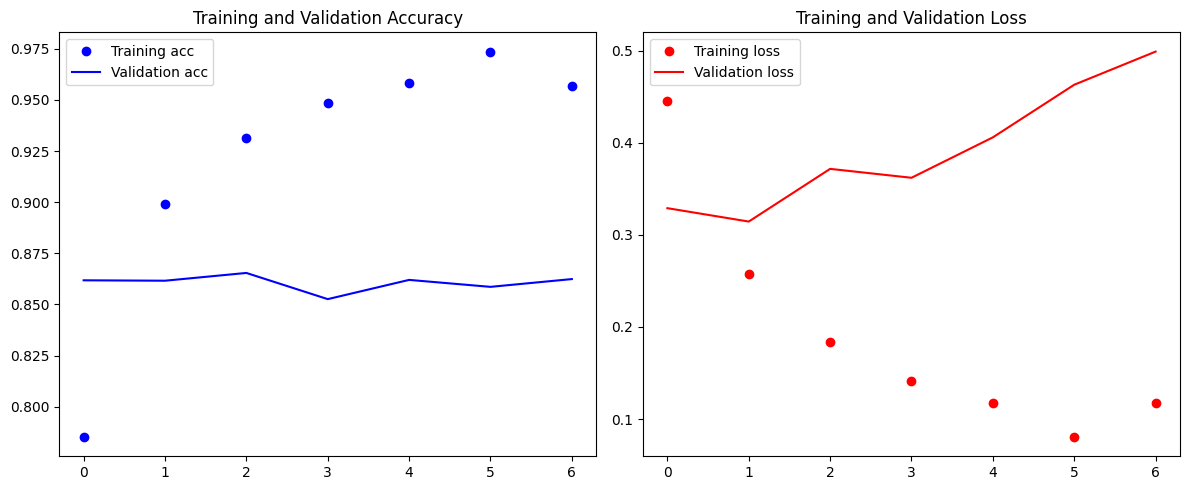

Test Accuracy: 85.19%
Test Loss: 0.5448
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step


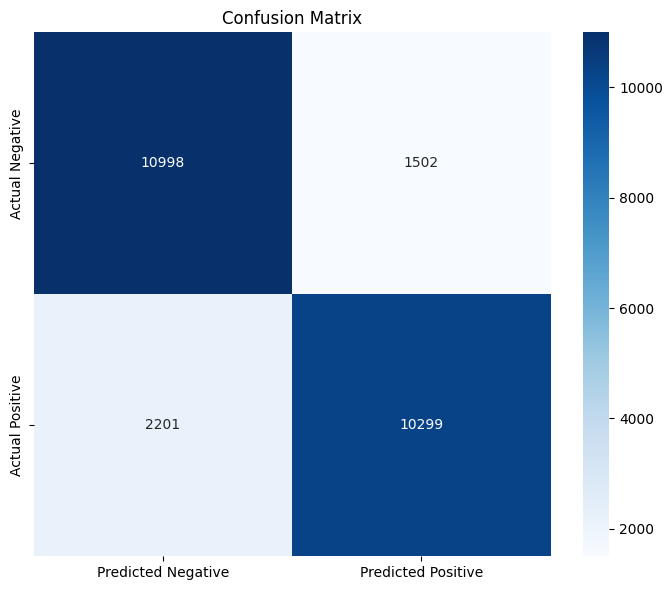

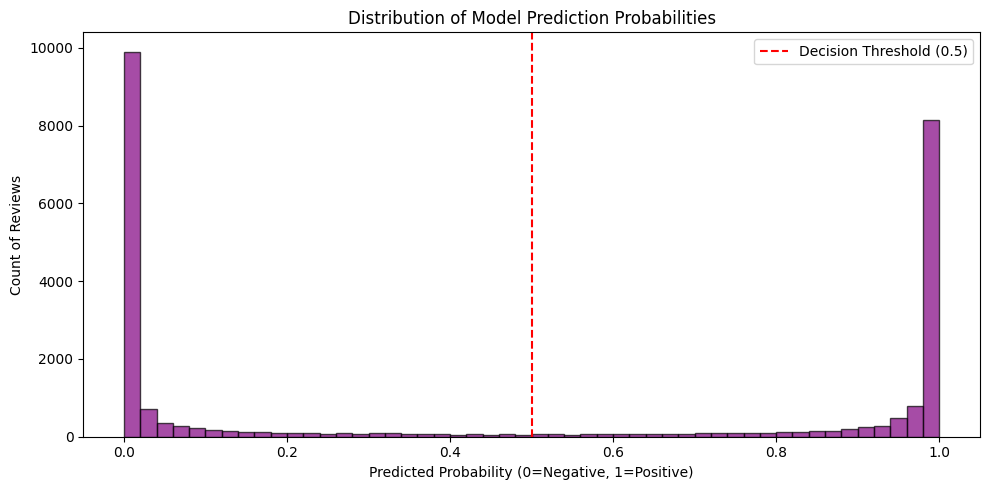

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Text: 'This movie was absolutely fantastic, loved every moment of i...'
Score: 0.2136
Prediction: NEGATIVE

Text: 'Terrible film, complete waste of time, would not recommend....'
Score: 0.5381
Prediction: POSITIVE

Text: 'The acting was brilliant and the storyline was deeply moving...'
Score: 0.8245
Prediction: POSITIVE

Text: 'Boring and predictable plot with no character development at...'
Score: 0.9218
Prediction: POSITIVE



In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Load Dataset
MAX_FEATURES = 10000
MAX_LEN = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)
x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN)
print(f"Training samples: {len(x_train)}, Test samples: {len(x_test)}")

# 2. Build LSTM Model
model = Sequential([
    Embedding(input_dim=MAX_FEATURES, output_dim=128, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 3. Train
history = model.fit(x_train, y_train, epochs=7, batch_size=64,
                    validation_split=0.2, verbose=1)

# 4. Accuracy Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'bo', label='Training acc')
plt.plot(history.history['val_accuracy'], 'b', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'ro', label='Training loss')
plt.plot(history.history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('p9_curves.png', dpi=150)
plt.show()

# 5. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 6. Confusion Matrix
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative','Predicted Positive'],
            yticklabels=['Actual Negative','Actual Positive'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('p9_confusion.png', dpi=150)
plt.show()

# 7. Prediction Probability Distribution
plt.figure(figsize=(10,5))
plt.hist(y_pred_probs, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title('Distribution of Model Prediction Probabilities')
plt.xlabel('Predicted Probability (0=Negative, 1=Positive)')
plt.ylabel('Count of Reviews')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.savefig('p9_dist.png', dpi=150)
plt.show()

# 8. Custom predictions
word_index = imdb.get_word_index()
def predict_review(text):
    tokens = [word_index.get(w.lower(), 2) for w in text.split()]
    tokens = [t if t < MAX_FEATURES else 2 for t in tokens]
    padded = pad_sequences([tokens], maxlen=MAX_LEN)
    score = model.predict(padded, verbose=0)[0][0]
    label = "POSITIVE" if score > 0.5 else "NEGATIVE"
    print(f"Text: '{text[:60]}...'\nScore: {score:.4f}\nPrediction: {label}\n")

predict_review("This movie was absolutely fantastic, loved every moment of it!")
predict_review("Terrible film, complete waste of time, would not recommend.")
predict_review("The acting was brilliant and the storyline was deeply moving.")
predict_review("Boring and predictable plot with no character development at all.")